(note)
main_torch의 레이어 구성 및 증강 기법으로 레이어 재구성
가속없이 돌리면 8시간정도 예상

In [1]:
import os
import numpy as np
import pickle
import matplotlib.pyplot as plt
import psutil

from time import time
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from collections import OrderedDict

# Load custom modules
from common.functions import *
from common.gradient import *
from common.layers import *
from common.multi_layer_net_extend import MultiLayerNetExtend
from common.multi_layer_net import MultiLayerNet
from common.optimizer import *
from common.trainer import Trainer
from common.util import *

# 한글 폰트 및 마이너스 기호 표시 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# numpy 멀티스레드 설정 - 최대 CPU 코어 수에 맞춰서 설정
# 에러나는경우 PC 사양에 따라 수동 조절
cpu_count = str(psutil.cpu_count(logical=False))
os.environ["OMP_NUM_THREADS"] = cpu_count
os.environ["OPENBLAS_NUM_THREADS"] = cpu_count
os.environ["MKL_NUM_THREADS"] = cpu_count
os.environ["VECLIB_MAXIMUM_THREADS"] = cpu_count
os.environ["NUMEXPR_NUM_THREADS"] = cpu_count
ram_size = psutil.virtual_memory().total / (1024 ** 3) # 최대 램용량 저장
print(f"CPU 코어 수: {cpu_count}, RAM 크기: {ram_size:.2f}GB")

CPU 코어 수: 14, RAM 크기: 15.59GB


---
### 데이터 로드

In [3]:
# CIFAR-100 데이터 로드 함수
def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

data_path = './cifar-100-python'
# 데이터 경로 설정
train_path = os.path.join(data_path, 'train')
test_path = os.path.join(data_path, 'test')

# 학습 데이터 로드
train_data = unpickle(train_path)
test_data = unpickle(test_path)

# 메타데이터 로드 (클래스 이름 등)
meta_path = os.path.join(data_path, 'meta')
meta_data = unpickle(meta_path)

fine_label_names = [name.decode() for name in meta_data[b'fine_label_names']]
coarse_label_names = [name.decode() for name in meta_data[b'coarse_label_names']]

# 데이터 구조 확인
print("학습 데이터 키:", [key.decode() if isinstance(key, bytes) else key for key in train_data.keys()])
print("테스트 데이터 키:", [key.decode() if isinstance(key, bytes) else key for key in test_data.keys()])
print("메타 데이터 키:", [key.decode() if isinstance(key, bytes) else key for key in meta_data.keys()])

학습 데이터 키: ['filenames', 'batch_label', 'fine_labels', 'coarse_labels', 'data']
테스트 데이터 키: ['filenames', 'batch_label', 'fine_labels', 'coarse_labels', 'data']
메타 데이터 키: ['fine_label_names', 'coarse_label_names']


In [4]:
print('파일 이름 갯수:',len(train_data[b'filenames'])) # 학습 데이터의 파일 이름
print('이미지 shape:', train_data[b'data'][:].shape) # 32*32*3 = 3072)
print('class len:', len(train_data[b'fine_labels'])) # 50,000
print('superclass len:', len(train_data[b'coarse_labels'])) # 50,000

파일 이름 갯수: 50000
이미지 shape: (50000, 3072)
class len: 50000
superclass len: 50000


In [5]:
print(len(meta_data[b'fine_label_names'])) # 100개의 클래스 이름
print(len(meta_data[b'coarse_label_names'])) # 20개의 클래스 이름

100
20


---
### 데이터 시각화

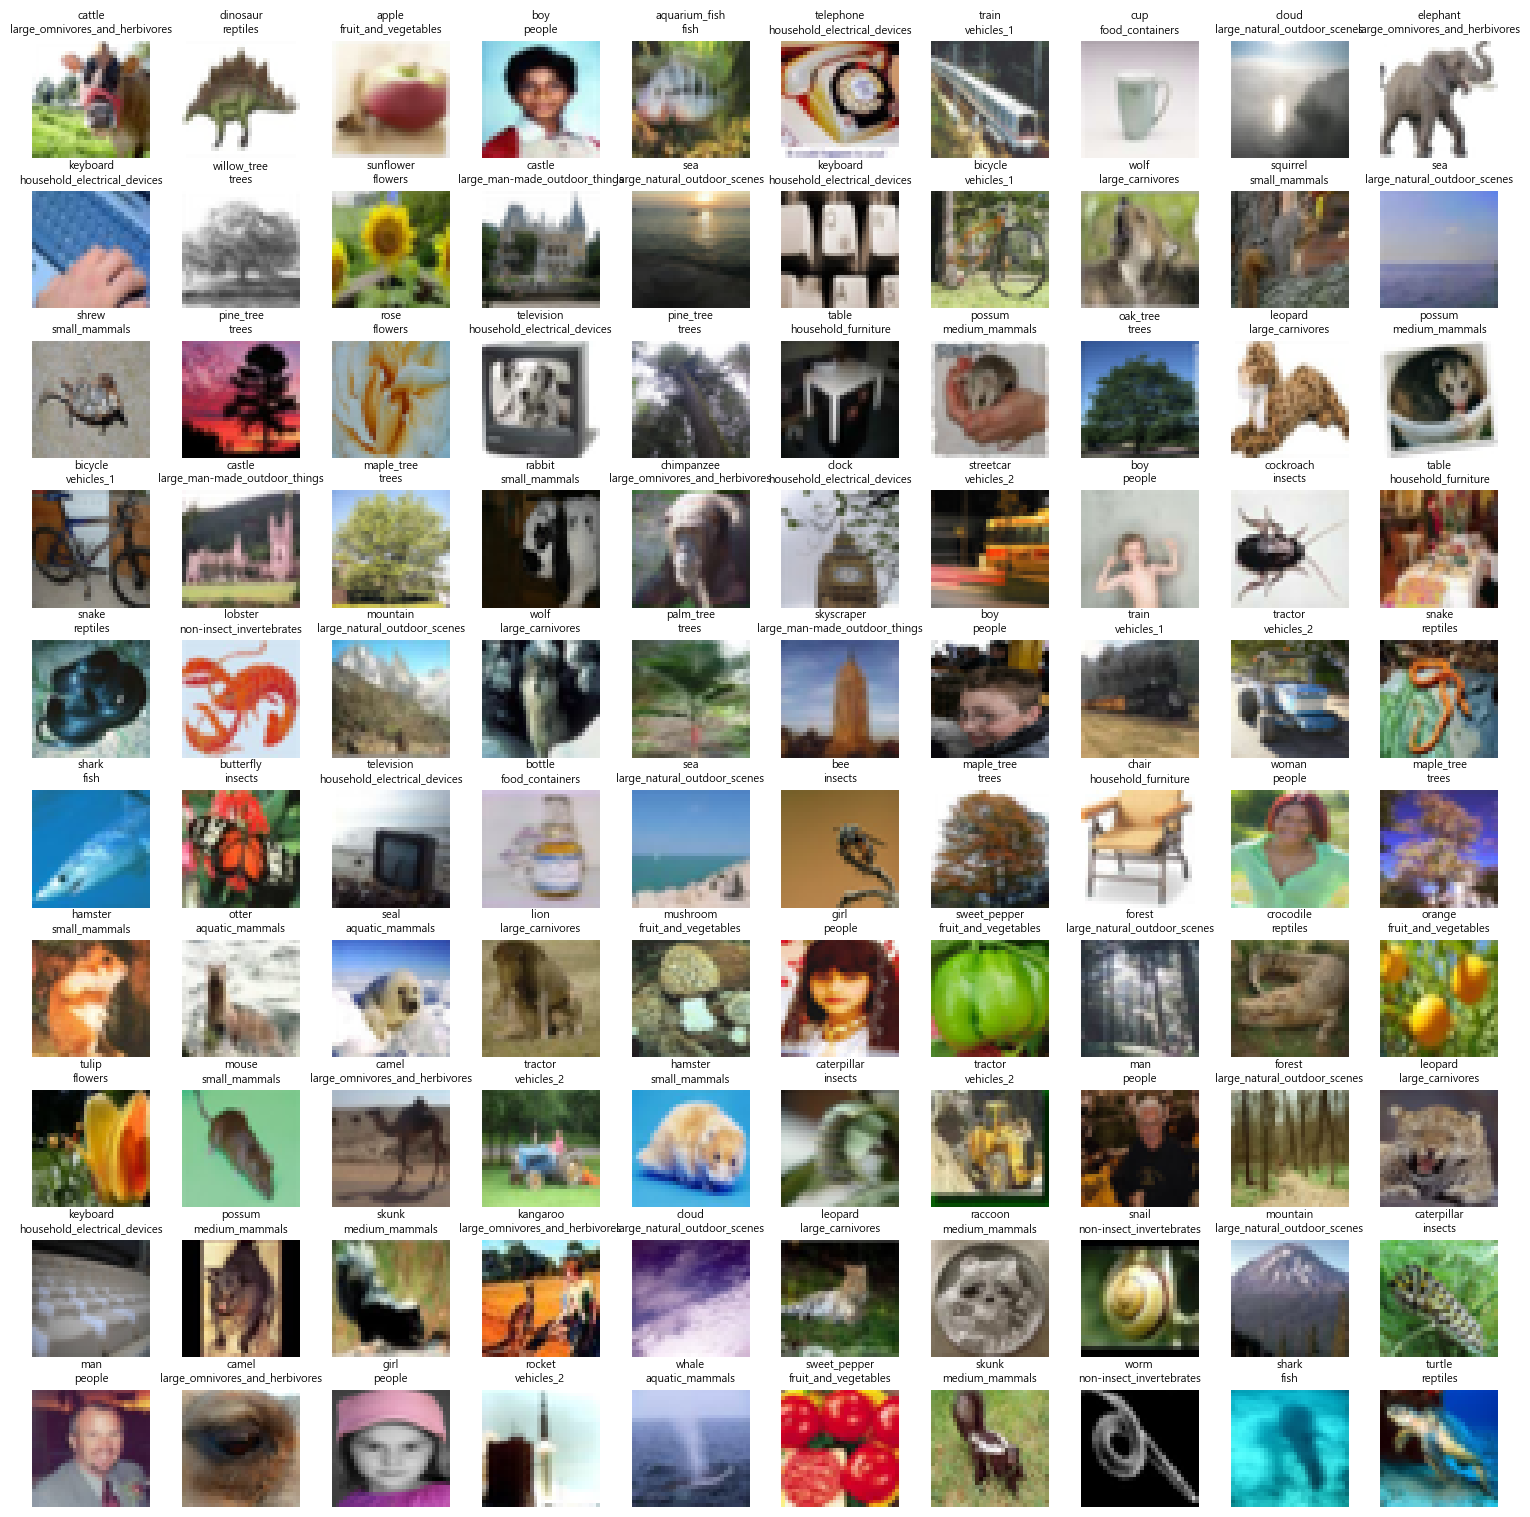

In [6]:
plt.figure(figsize=(15, 15))
for i in range(100):
    img = train_data[b'data'][i]
    img = img.reshape(3, 32, 32).transpose(1, 2, 0)
    img = img / 255.0

    fine_idx = train_data[b'fine_labels'][i]
    coarse_idx = train_data[b'coarse_labels'][i]
    fine_label = fine_label_names[fine_idx]
    coarse_label = coarse_label_names[coarse_idx]

    plt.subplot(10, 10, i + 1)
    plt.imshow(img)
    plt.title(f"{fine_label}\n{coarse_label}", fontsize=8)
    plt.axis('off')
    plt.subplots_adjust(wspace=0.05, hspace=0.05)  # 이미지 간격 최소화

plt.tight_layout(pad=0.1)
plt.show()

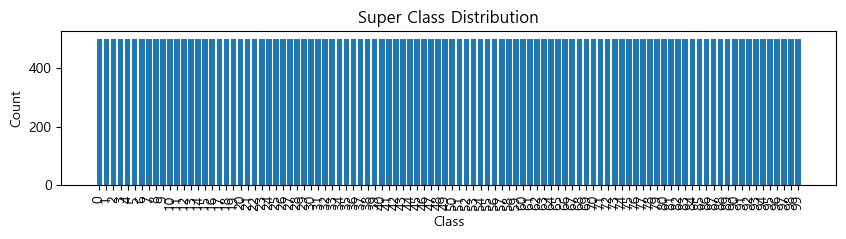

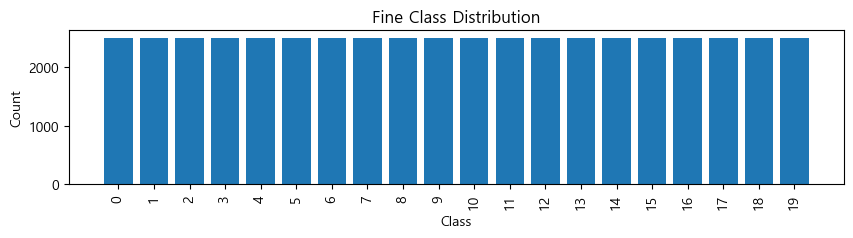

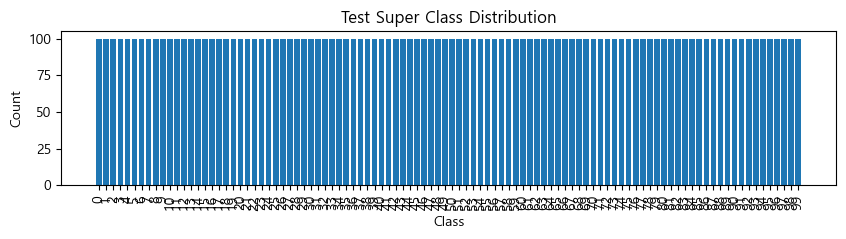

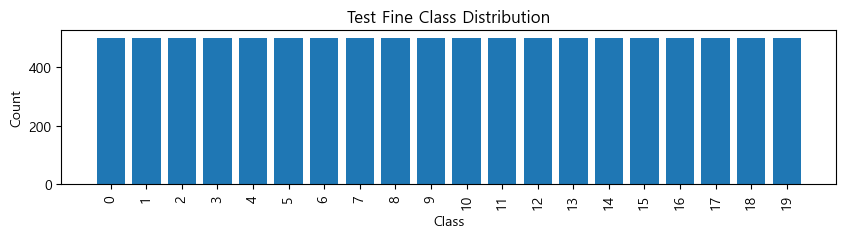

In [7]:
# 클래스 통계
def class_counts(data):
    unique, counts = np.unique(data[b'fine_labels'], return_counts=True)
    superclass_dict = dict(zip(unique, counts))
    unique, counts = np.unique(data[b'coarse_labels'], return_counts=True)
    class_dict = dict(zip(unique, counts))
    return superclass_dict, class_dict
superclass_counts, fineclass_counts = class_counts(train_data)
t_superclass_counts, t_fineclass_counts = class_counts(test_data)

# 클래스 통계 시각화
def plot_class_distribution(class_counts, title):
    plt.figure(figsize=(10, 2))
    plt.bar(class_counts.keys(), class_counts.values())
    plt.xticks(list(class_counts.keys()), rotation=90)
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.title(title)
    plt.show()
plot_class_distribution(superclass_counts, 'Super Class Distribution')
plot_class_distribution(fineclass_counts, 'Fine Class Distribution')
plot_class_distribution(t_superclass_counts, 'Test Super Class Distribution')
plot_class_distribution(t_fineclass_counts, 'Test Fine Class Distribution')

---
### 데이터 전처리

In [8]:
# ----------------------------- #
# AutoAugment 고정 정책 기반 구현
# ----------------------------- #

# 각 증강 함수 정의
def flip(img, _):
    return np.flip(img, axis=2)  # 좌우반전

def cutout(img, size):
    _, h, w = img.shape
    y, x = np.random.randint(h), np.random.randint(w)
    y1, y2 = max(0, y-size//2), min(h, y+size//2)
    x1, x2 = max(0, x-size//2), min(w, x+size//2)
    img[:, y1:y2, x1:x2] = 0
    return img

def brightness(img, factor):  # factor: 0.0~1.0
    scale = 1 + factor * (np.random.rand() * 2 - 1)
    return np.clip(img * scale, 0, 1)

def contrast(img, factor):
    mean = np.mean(img, axis=(1,2), keepdims=True)
    scale = 1 + factor * (np.random.rand() * 2 - 1)
    return np.clip((img - mean) * scale + mean, 0, 1)

def crop(img, pad=4):  # 랜덤 패딩 크롭
    C, H, W = img.shape
    padded = np.pad(img, ((0, 0), (pad, pad), (pad, pad)), mode='reflect')
    top = np.random.randint(0, 2 * pad)
    left = np.random.randint(0, 2 * pad)
    return padded[:, top:top+H, left:left+W]

# 연산 사전
AUGMENT_FN = {
    'flip': flip,
    'cutout': cutout,
    'brightness': brightness,
    'contrast': contrast,
    'crop': crop,
}

# 고정된 AutoAugment 스타일 정책
AUGMENT_POLICIES = [
    [('flip', 0.8, None), ('brightness', 0.6, 0.3)],
    [('cutout', 0.7, 8), ('contrast', 0.5, 0.5)],
    [('crop', 1.0, 4), ('cutout', 0.5, 4)],  # ✅ mag=None → 4로 수정
]

# 이미지 1장에 대해 정책 적용
def apply_policy(img, policy):
    for op_name, prob, mag in policy:
        if np.random.rand() < prob:
            img = AUGMENT_FN[op_name](img, mag)
    return img

# 전체 배치 증강
def autoaugment_batch(x_batch):
    N = x_batch.shape[0]
    new_batch = np.empty_like(x_batch)
    for i in range(N):
        policy = AUGMENT_POLICIES[np.random.randint(len(AUGMENT_POLICIES))]
        new_batch[i] = apply_policy(x_batch[i], policy)
    return new_batch


In [9]:
def one_hot_encode(y, num_classes):
    return np.eye(num_classes)[y.astype(int)]

# train set 으로 validation set 분할
x = train_data[b'data']
x = x.reshape(-1, 3, 32, 32)
t = np.array(train_data[b'coarse_labels'])
x_train, x_val, y_train, y_val = train_test_split(x, t, test_size=0.2, random_state=42, stratify=t)

# test set 정의
x_test = test_data[b'data']
x_test = x_test.reshape(-1, 3, 32, 32)
y_test = np.array(test_data[b'coarse_labels'])

x_test = x_test.astype(np.float32) / 255.0
x_train = x_train.astype(np.float32) / 255.0
x_val = x_val.astype(np.float32) / 255.0

y_train = one_hot_encode(y_train, 20)
y_val = one_hot_encode(y_val, 20)
y_test = one_hot_encode(y_test, 20)

x_train.shape, x_val.shape, x_test.shape, y_train.shape, y_val.shape, y_test.shape

((40000, 3, 32, 32),
 (10000, 3, 32, 32),
 (10000, 3, 32, 32),
 (40000, 20),
 (10000, 20),
 (10000, 20))

---
### 모델 정의 및 학습

In [10]:
# 기존 util.py 응용 - 출력을 정수형으로 변경
def conv_output_size(input_size, filter_size, stride=1, pad=0):
    return int((input_size + 2*pad - filter_size) / stride + 1)
def pool_output_size(input_size, pool_size, stride):
    return int(1 + (input_size - pool_size) / stride)

In [11]:
class CustomCNN:
    # 모델 구조
    # ConvB1 : C1(16) -> R -> C2(32) -> R -> P1
    # ConvB2 : C3(64) -> R -> C4(128) -> R -> P2
    # Dense1 : Affine1(256) -> R -> BN1 -> Drop1
    # Dense2 : Affine2(256) -> R -> BN2 -> Drop2
    # Affine_out(output_size)
    # util.py 내 im2col 연산 float32로 변경 필요
    def __init__(self, input_dim=(3, 32, 32),
                C1={'filter_num':16, 'filter_size':3, 'pad':1, 'stride':1},
                C2={'filter_num':32, 'filter_size':3, 'pad':1, 'stride':1},
                P1={'pool_h':2, 'pool_w':2, 'stride':2},
                C3={'filter_num':64, 'filter_size':3, 'pad':1, 'stride':1},
                C4={'filter_num':128, 'filter_size':3, 'pad':1, 'stride':1},
                P2={'pool_h':2, 'pool_w':2, 'stride':2},
                weight_init_std=0.01,
                fc_hidden_size_list=[256,256], fc_output_size=20,
                fc_activation='relu', fc_weight_std='he',
                fc_dropout_ratio=0.5, fc_use_batchnorm=True,
                verbose=True):
        
        self.verbose = verbose
        self.use_dropout = fc_dropout_ratio > 0
        self.use_batchnorm = fc_use_batchnorm
        self.fc_dropout_ratio = fc_dropout_ratio
        self.weight_init_std = weight_init_std # 가중치 초기화 방법 지정(또는 숫자)

        # Input, Conv, Pooling params
        input_c, input_h, input_w = input_dim
        if verbose: print(f"Input shape: {input_dim}")  # 추가: 입력 shape 확인
            # ConvB1
        C1_fn, C1_fs, C1_p, C1_s= C1['filter_num'], C1['filter_size'], C1['pad'], C1['stride']
        C2_fn, C2_fs, C2_p, C2_s= C2['filter_num'], C2['filter_size'], C2['pad'], C2['stride']
        P1_ph, P1_pw, P1_s= P1['pool_h'], P1['pool_w'], P1['stride']
           # ConvB2
        C3_fn, C3_fs, C3_p, C3_s= C3['filter_num'], C3['filter_size'], C3['pad'], C3['stride']
        C4_fn, C4_fs, C4_p, C4_s= C4['filter_num'], C4['filter_size'], C4['pad'], C4['stride']
        P2_ph, P2_pw, P2_s= P2['pool_h'], P2['pool_w'], P2['stride']
        
        #layer_init 전달용, 레이어 구성 바뀌면 바꿔야함
        self.layer_settings = {'C1_s':C1_s, 'C1_p':C1_p, 'C2_s':C2_s, 'C2_p':C2_p,
                               'P1_ph':P1_ph, 'P1_pw':P1_pw, 'P1_s':P1_s,
                               'C3_s':C3_s, 'C3_p':C3_p, 'C4_s':C4_s, 'C4_p':C4_p,
                               'P2_ph':P2_ph, 'P2_pw':P2_pw, 'P2_s':P2_s}
           
        # Conv, Pooling Shape
            # ConvB1
        C1_out_h = conv_output_size(input_h, C1_fs, C1_s, C1_p)
        C1_out_w = conv_output_size(input_w, C1_fs, C1_s, C1_p)
        C2_out_h = conv_output_size(C1_out_h, C2_fs, C2_s, C2_p)
        C2_out_w = conv_output_size(C1_out_w, C2_fs, C2_s, C2_p)
        P1_out_h = pool_output_size(C2_out_h, P1_ph, P1_s)
        P1_out_w = pool_output_size(C2_out_w, P1_pw, P1_s)
            # ConvB2
        C3_out_h = conv_output_size(P1_out_h, C3_fs, C3_s, C3_p)
        C3_out_w = conv_output_size(P1_out_w, C3_fs, C3_s, C3_p)
        C4_out_h = conv_output_size(C3_out_h, C4_fs, C4_s, C4_p)
        C4_out_w = conv_output_size(C3_out_w, C4_fs, C4_s, C4_p)
        P2_out_h = pool_output_size(C4_out_h, P2_ph, P2_s)
        P2_out_w = pool_output_size(C4_out_w, P2_pw, P2_s)
            # Affine Size
        fc_input_size = int(C4_fn * P2_out_h * P2_out_w)
        if verbose: print(f"FC input size: {fc_input_size}")  # 추가

        # 가중치 초기화
        self.params = {}
        self.bn_params = {}
            #ConvB1
        self.params['W1'] = self._get_init_weight(prev_node_num=input_c*C1_fs**2) * np.random.randn(C1_fn, input_c, C1_fs, C1_fs)
        self.params['b1'] = np.zeros(C1_fn, dtype=np.float32)
        self.params['W2'] = self._get_init_weight(prev_node_num=C1_fn*C2_fs**2) * np.random.randn(C2_fn, C1_fn, C2_fs, C2_fs)
        self.params['b2'] = np.zeros(C2_fn, dtype=np.float32)
            #ConvB2
        self.params['W3'] = self._get_init_weight(prev_node_num=C2_fn*C3_fs**2) * np.random.randn(C3_fn, C2_fn, C3_fs, C3_fs)
        self.params['b3'] = np.zeros(C3_fn, dtype=np.float32)
        self.params['W4'] = self._get_init_weight(prev_node_num=C3_fn*C4_fs**2) * np.random.randn(C4_fn, C3_fn, C4_fs, C4_fs)
        self.params['b4'] = np.zeros(C4_fn, dtype=np.float32)
            # FC Layer
        self.params['W5'] = self._get_init_weight(prev_node_num=fc_input_size) * np.random.randn(fc_input_size, fc_hidden_size_list[0])
        self.params['b5'] = np.zeros(fc_hidden_size_list[0], dtype=np.float32)
        self.params['W6'] = self._get_init_weight(prev_node_num=fc_hidden_size_list[0]) * np.random.randn(fc_hidden_size_list[0], fc_hidden_size_list[1])
        self.params['b6'] = np.zeros(fc_hidden_size_list[1], dtype=np.float32)
        self.params['W7'] = self._get_init_weight(prev_node_num=fc_hidden_size_list[1]) * np.random.randn(fc_hidden_size_list[1], fc_output_size)
        self.params['b7'] = np.zeros(fc_output_size, dtype=np.float32)
            # BN
        if fc_use_batchnorm:
            self.params['gamma5'] = np.ones(fc_hidden_size_list[0])
            self.params['beta5'] = np.zeros(fc_hidden_size_list[0], dtype=np.float32)
            self.bn_params['running_mean5'] = np.zeros(fc_hidden_size_list[0], dtype=np.float32)
            self.bn_params['running_var5'] = np.ones(fc_hidden_size_list[0], dtype=np.float32)
            self.params['gamma6'] = np.ones(fc_hidden_size_list[1])
            self.params['beta6'] = np.zeros(fc_hidden_size_list[1], dtype=np.float32)
            self.bn_params['running_mean6'] = np.zeros(fc_hidden_size_list[1], dtype=np.float32)
            self.bn_params['running_var6'] = np.ones(fc_hidden_size_list[1], dtype=np.float32)
        # 레이어 구성 함수 호출
        self._layer_init(self.layer_settings)
    
    def _layer_init(self, layer_setting):
        # 레이어 구성
        self.layers = OrderedDict()
            # ConvB1
        self.layers['C1'] = Convolution(self.params['W1'], self.params['b1'], stride=layer_setting['C1_s'], pad=layer_setting['C1_p'])
        self.layers['R1'] = Relu()
        self.layers['C2'] = Convolution(self.params['W2'], self.params['b2'], stride=layer_setting['C2_s'], pad=layer_setting['C2_p'])
        self.layers['R2'] = Relu()
        self.layers['P1'] = Pooling(pool_h=layer_setting['P1_ph'], pool_w=layer_setting['P1_pw'], stride=layer_setting['P1_s'])
            # ConvB2
        self.layers['C3'] = Convolution(self.params['W3'], self.params['b3'], stride=layer_setting['C3_s'], pad=layer_setting['C3_p'])
        self.layers['R3'] = Relu()
        self.layers['C4'] = Convolution(self.params['W4'], self.params['b4'], stride=layer_setting['C4_s'], pad=layer_setting['C4_p'])
        self.layers['R4'] = Relu()
        self.layers['P2'] = Pooling(pool_h=layer_setting['P2_ph'], pool_w=layer_setting['P2_pw'], stride=layer_setting['P2_s'])
            # FC B1
        self.layers['Affine1'] = Affine(self.params['W5'], self.params['b5'])
        if self.use_batchnorm: self.layers['BN1'] = BatchNormalization(self.params['gamma5'], self.params['beta5'], running_mean=self.bn_params['running_mean5'], running_var=self.bn_params['running_var5'])
        self.layers['R5'] = Relu()
        if self.use_dropout: self.layers['Drop1'] = Dropout(self.fc_dropout_ratio)
            # FC B2
        self.layers['Affine2'] = Affine(self.params['W6'], self.params['b6'])
        if self.use_batchnorm: self.layers['BN2'] = BatchNormalization(self.params['gamma6'], self.params['beta6'], running_mean=self.bn_params['running_mean6'], running_var=self.bn_params['running_var6'])
        self.layers['R6'] = Relu()
        if self.use_dropout: self.layers['Drop2'] = Dropout(self.fc_dropout_ratio)
            # Output
        self.layers['Affine_out'] = Affine(self.params['W7'], self.params['b7'])
        self.last_layer = SoftmaxWithLoss()

    def _get_init_weight(self, prev_node_num = None):
        if self.weight_init_std == 'relu' or self.weight_init_std == 'he':
            return np.sqrt(2.0 / prev_node_num)
        else:
            return self.weight_init_std

    def predict(self, x, train_flg=False):
        for name, layer in self.layers.items():
            if isinstance(layer, (Dropout, BatchNormalization)):
                x = layer.forward(x, train_flg)
            else:
                x = layer.forward(x)
            if self.verbose:
                print(f"{name} output shape: {x.shape}")
                if name in ['Affine1', 'Affine2'] and not self.use_batchnorm:
                    print(f"  Stats for {name} output (pre-ReLU): mean={np.mean(x):.4f}, std={np.std(x):.4f}, min={np.min(x):.4f}, max={np.max(x):.4f}")
        return x

    def loss(self, x, t, train_flg=False):
        y = self.predict(x, train_flg)
        return self.last_layer.forward(y, t)

    def accuracy(self, x, t, train_flg=False):
        y = self.predict(x, train_flg)
        y = np.argmax(y, axis=1)
        if t.ndim != 1:
            t = np.argmax(t, axis=1)
        return np.sum(y == t) / float(x.shape[0])
    
    # 램용량 넘쳐서 batch 처리
    def batch_loss(self, x, t, batch_size=100, label="Loss"):
        loss = 0
        size = x.shape[0]
        for i in tqdm(range(0, size, batch_size), desc=label, leave=False):
            x_batch = x[i:i+batch_size]
            t_batch = t[i:i+batch_size]
            loss += self.loss(x_batch, t_batch) * x_batch.shape[0]
        return loss / size

    def batch_accuracy(self, x, t, batch_size=100, label="Acc"):
        acc = 0
        size = x.shape[0]
        for i in tqdm(range(0, size, batch_size), desc=label, leave=False):
            x_batch = x[i:i+batch_size]
            t_batch = t[i:i+batch_size]
            acc += np.sum(self.accuracy(x_batch, t_batch) * x_batch.shape[0])
        return acc / size

    def gradient(self, x, t):
        # Forward
        self.loss(x, t, train_flg=True) # 학습모드
        # Backward
        dout = self.last_layer.backward(1)
        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)
        # Grads dict
        grads = {}
        # Conv
        for i in range(1, 5):
            grads[f'W{i}'] = self.layers[f'C{i}'].dW
            grads[f'b{i}'] = self.layers[f'C{i}'].db
        # FC
        grads['W5'] = self.layers['Affine1'].dW
        grads['b5'] = self.layers['Affine1'].db
        grads['W6'] = self.layers['Affine2'].dW
        grads['b6'] = self.layers['Affine2'].db
        grads['W7'] = self.layers['Affine_out'].dW
        grads['b7'] = self.layers['Affine_out'].db
        # BN
        if 'BN1' in self.layers:
            grads['gamma5'] = self.layers['BN1'].dgamma
            grads['beta5'] = self.layers['BN1'].dbeta
            self.bn_params['running_mean5'] = self.layers['BN1'].running_mean
            self.bn_params['running_var5'] = self.layers['BN1'].running_var
        if 'BN2' in self.layers:
            grads['gamma6'] = self.layers['BN2'].dgamma
            grads['beta6'] = self.layers['BN2'].dbeta
            self.bn_params['running_mean6'] = self.layers['BN2'].running_mean
            self.bn_params['running_var6'] = self.layers['BN2'].running_var
        return grads

    def save_params(self, file_name="custom_cnn_final_params.npz"):
        try:
            save_dict = {**self.params, **self.bn_params}
            np.savez_compressed(file_name, **save_dict)
            return f"Parameters saved to {file_name}!"
        except Exception as e:
            return f"Save failed: {type(e).__name__}: {e}"

    def load_params(self, file_name="custom_cnn_final_params.npz"):
        loaded = np.load(file_name, allow_pickle=True)
        for key in self.params.keys():
            if key in loaded:
                self.params[key] = loaded[key]
        for key in self.bn_params.keys():
            if key in loaded:
                self.bn_params[key] = loaded[key]
        self._layer_init(self.layer_settings)
        print(f"Parameters loaded from {file_name}!")

In [12]:
class CustomTrainer:
    """
    신경망 훈련을 수행하는 클래스.
    학습, 검증, 테스트 데이터를 모두 사용하며, 학습 과정을 기록하고 최적 모델을 저장합니다.
    """
    def __init__(self, network, 
                 x_train, t_train, x_val, t_val, x_test, t_test,
                 epochs=20, mini_batch_size=100,
                 optimizer='Adam', optimizer_param={'lr':0.001}, 
                 verbose=True, model_save_path='best_model.npz',
                 weight_decay_lambda=0.0001,
                 use_augmentation=True, augmentation_param={'num_aug':5000, 'initial_seed':42}):
        
        self.network = network
        self.x_train = x_train
        self.t_train = t_train
        self.x_val = x_val
        self.t_val = t_val
        self.x_test = x_test
        self.t_test = t_test
        
        self.epochs = epochs
        self.batch_size = mini_batch_size
        self.verbose = verbose
        self.model_save_path = model_save_path

        # Optimizer 설정
        optimizer_class_dict = {'sgd':SGD, 'momentum':Momentum, 'nesterov':Nesterov,
                                'adagrad':AdaGrad, 'rmsprop':RMSprop, 'adam':Adam}
        self.optimizer = optimizer_class_dict[optimizer.lower()](**optimizer_param)
        
        self.current_x_train = self.x_train
        self.current_t_train = self.t_train
        self.train_size = self.current_x_train.shape[0]
        self.iter_per_epoch = max(self.train_size // self.batch_size, 1)  # 정수 나눗셈
        self.max_iter = int(epochs * self.iter_per_epoch)
        
        self.best_val_loss = float('inf')
        self.history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    def _train_step(self):
        batch_mask = np.random.choice(self.train_size, self.batch_size)
        x_batch = self.current_x_train[batch_mask]
        t_batch = self.current_t_train[batch_mask]
        
        # AutoAugment (optional)
        x_batch = autoaugment_batch(x_batch)

        # 기울기 계산 및 파라미터 갱신
        grads = self.network.gradient(x_batch, t_batch)
        self.optimizer.update(self.network.params, grads)
    
    def train(self):
        for epoch in range(1, self.epochs + 1):
            # tqdm을 사용하여 미니배치 학습 진행 표시
            with tqdm(range(self.iter_per_epoch), desc=f"Epoch {epoch}/{self.epochs}", unit="batch", mininterval=1) as pbar:
                for _ in pbar:
                    self._train_step()

            # --- 1 에포크 종료 후 평가 ---
            # 학습 데이터에 대한 손실 및 정확도
            current_train_loss = self.network.batch_loss(self.current_x_train, self.current_t_train, batch_size=self.batch_size, label="Train Loss")
            current_train_acc = self.network.batch_accuracy(self.current_x_train, self.current_t_train, batch_size=self.batch_size, label="Train Acc")

            # 검증 데이터에 대한 손실 및 정확도
            current_val_loss = self.network.batch_loss(self.x_val, self.t_val, batch_size=self.batch_size, label="Val Loss")
            current_val_acc = self.network.batch_accuracy(self.x_val, self.t_val, batch_size=self.batch_size, label="Val Acc")

            # History 기록
            self.history['train_loss'].append(current_train_loss)
            self.history['train_acc'].append(current_train_acc)
            self.history['val_loss'].append(current_val_loss)
            self.history['val_acc'].append(current_val_acc)

            if self.verbose:
                print(f"  - Train Loss: {current_train_loss:.4f}, Train Acc: {current_train_acc:.4f} / "
                      f"Val Loss: {current_val_loss:.4f}, Val Acc: {current_val_acc:.4f}")

            # 최소 검증 손실 모델 저장
            if current_val_loss < self.best_val_loss:
                self.best_val_loss = current_val_loss
                save_msg = self.network.save_params(self.model_save_path)
                if self.verbose:
                    print(f"  -> Best model saved. {save_msg} (Val Loss: {self.best_val_loss:.4f})", flush=True)
        
        # --- 학습 종료 후 최종 테스트 평가 ---
        if self.verbose:
            print("\n=============== Final Test Evaluation ===============")
        # Best 모델 로드 - 수정된 후 활성화
        if self.verbose: print(f"Loading best model from {self.model_save_path}...")
        self.network.load_params(self.model_save_path)
        # 테스트 데이터에 대한 손실 및 정확도
        if ram_size < 18:
            test_loss = self.network.batch_loss(self.x_test, self.t_test, batch_size=self.batch_size, label="Test Loss")
            test_acc = self.network.batch_accuracy(self.x_test, self.t_test, batch_size=self.batch_size, label="Test Acc")
        else:
            test_loss = self.network.loss(self.x_test, self.t_test, train_flg=False)
            test_acc = self.network.accuracy(self.x_test, self.t_test)
        
        if self.verbose:
            print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")
            
        return self.history

In [13]:
def write_param_note(model_path, time_date, model_note, model_settings=None, trainer_settings=None):
    param_notes = f"time_date: {time_date}\n"

    param_notes += "모델 세팅 :\n"
    for key, value in model_settings.items():
        param_notes += f"    {key}: {value}\n"

    param_notes += "트레이너 세팅:\n"
    for key, value in trainer_settings.items():
        param_notes += f"    {key}: {value}\n"
    param_notes += f"""모델 노트:
    {model_note}
    """
    file_note = open(model_path+'/model_param.txt', 'w')
    file_note.write(param_notes)
    print(f"모델 세팅 노트 작성 완료: {model_path}/model_param.txt")
    file_note.close()


In [14]:
time_date = '250521_1030'
model_path = f'./saved_model/model_{time_date}'
os.makedirs(model_path, exist_ok=True) # 모델 경로가 존재하지 않으면 생성
# 훈련 파라미터 세팅 및 저장
model_params={
    'dropout_ratio' : 0.3,
    'use_batchnorm' : True,
    'weight_init_std' : 'he'
}
trainer_params={
    'epochs' : 50,
    'mini_batch_size' : 1024,
    'optimizer' : 'Adam',
    'optimizer_param' : {'lr':0.001},
}
model_note = "he 초기화와 0.01 초기화 비교"
write_param_note(model_path, time_date, model_note, model_params, trainer_params)

network = CustomCNN(verbose=False,
                    fc_dropout_ratio=model_params['dropout_ratio'],
                    fc_use_batchnorm=model_params['use_batchnorm'],
                    weight_init_std=model_params['weight_init_std'])
trainer = CustomTrainer(network, x_train, y_train, x_val, y_val, x_test, y_test,
                  epochs=trainer_params['epochs'],
                  mini_batch_size=trainer_params['mini_batch_size'], 
                  optimizer=trainer_params['optimizer'], 
                  optimizer_param=trainer_params['optimizer_param'],
                  model_save_path=model_path+'/custom_cnn_best_model.npz',
                  verbose=1)
history = trainer.train()
pickle.dump(history, open(model_path+'/custom_cnn_history.pkl', 'wb')) # history 저장

모델 세팅 노트 작성 완료: ./saved_model/model_250521_1030/model_param.txt


Epoch 1/50: 100%|██████████| 39/39 [07:49<00:00, 12.05s/batch]


  - Train Loss: 2.3174, Train Acc: 0.3010 / Val Loss: 2.3423, Val Acc: 0.2884
  -> Best model saved. Parameters saved to ./saved_model/model_250521_1030/custom_cnn_best_model.npz! (Val Loss: 2.3423)


Epoch 2/50: 100%|██████████| 39/39 [07:55<00:00, 12.19s/batch]


  - Train Loss: 1.9752, Train Acc: 0.3979 / Val Loss: 2.0352, Val Acc: 0.3725
  -> Best model saved. Parameters saved to ./saved_model/model_250521_1030/custom_cnn_best_model.npz! (Val Loss: 2.0352)


...

Epoch 49/50: 100%|██████████| 39/39 [07:37<00:00, 11.74s/batch]


  - Train Loss: 0.1009, Train Acc: 0.9830 / Val Loss: 1.3494, Val Acc: 0.6229


Epoch 50/50: 100%|██████████| 39/39 [07:43<00:00, 11.89s/batch]


  - Train Loss: 0.0920, Train Acc: 0.9851 / Val Loss: 1.3389, Val Acc: 0.6257

=============== Final Test Evaluation ===============
Loading best model from ./saved_model/model_250521_1030/custom_cnn_best_model.npz...
Parameters loaded from ./saved_model/model_250521_1030/custom_cnn_best_model.npz!


Test Loss: 1.2702, Test Accuracy: 0.6108


In [16]:
time_date = '250521_1030'
model_path = f'./saved_model/model_{time_date}'
history = pickle.load(open(model_path+'/custom_cnn_history.pkl', 'rb')) # history load

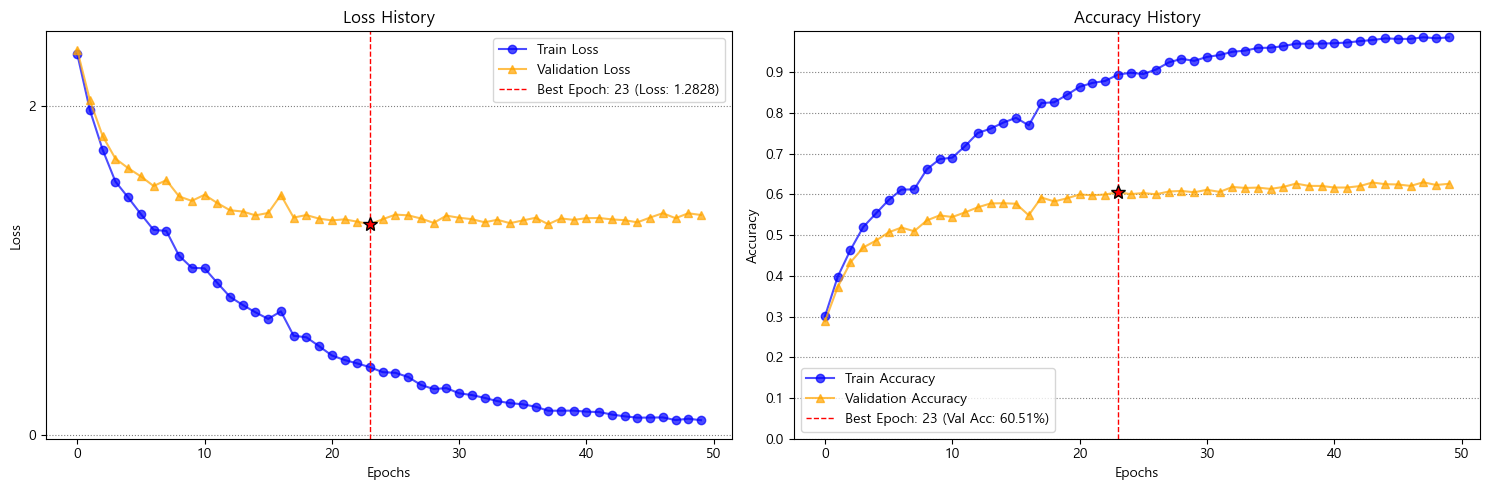

In [17]:
# History 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Validation Loss가 최소인 epoch 찾기
best_epoch_idx = np.argmin(history['val_loss'])
min_val_loss = history['val_loss'][best_epoch_idx]
val_acc_at_best_loss = history['val_acc'][best_epoch_idx]

# Loss
ax1.plot(history['train_loss'], marker='o', linestyle='-', label='Train Loss', color='blue', alpha=0.7)
ax1.plot(history['val_loss'], marker='^', linestyle='-', label='Validation Loss', color='orange', alpha=0.7)
ax1.set_title('Loss History')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')

# y축 그리드 설정 (2 간격)
y_min_loss, y_max_loss = ax1.get_ylim()
ax1.set_yticks(np.arange(np.floor(y_min_loss / 2) * 2, np.ceil(y_max_loss / 2) * 2 + 2, 2)) # 2 간격으로 눈금 설정
ax1.grid(axis='y', linestyle=':', color='gray')

# 최소 Validation Loss 지점 표시
ax1.axvline(x=best_epoch_idx, color='red', linestyle='--', linewidth=1, label=f'Best Epoch: {best_epoch_idx} (Loss: {min_val_loss:.4f})')
ax1.plot(best_epoch_idx, min_val_loss, marker='*', markersize=10, color='red', linestyle='None', markeredgecolor='black')
ax1.legend()

# Accuracy
ax2.plot(history['train_acc'], marker='o', linestyle='-', label='Train Accuracy', color='blue', alpha=0.7)
ax2.plot(history['val_acc'], marker='^', linestyle='-', label='Validation Accuracy', color='orange', alpha=0.7)
ax2.set_title('Accuracy History')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')

# y축 범위 및 그리드 설정 (0.0 ~ 0.9, 0.1 간격)
ax2.set_ylim(0.0, 1.0)
ax2.set_yticks(np.arange(0.0, 0.91, 0.1)) # 0.1 간격으로 눈금 설정
ax2.grid(axis='y', linestyle=':', color='gray')

# 최소 Validation Loss 지점 (Accuracy 플롯에도 동일 epoch 표시)
ax2.axvline(x=best_epoch_idx, color='red', linestyle='--', linewidth=1, label=f'Best Epoch: {best_epoch_idx} (Val Acc: {val_acc_at_best_loss*100:2.2f}%)')
ax2.plot(best_epoch_idx, val_acc_at_best_loss, marker='*', markersize=10, color='red', linestyle='None', markeredgecolor='black')
ax2.legend()

plt.tight_layout()
plt.show()

In [18]:
# Model Load

time_date = '250521_1030'
model_path = f'./saved_model/model_{time_date}'
network_temp = CustomCNN(verbose=False, fc_dropout_ratio=0.3, fc_use_batchnorm=True)
network_temp.load_params(model_path + '/custom_cnn_best_model.npz')

# Test Accuracy
test_loss_temp = network_temp.batch_loss(x_test, y_test)
test_acc_temp = network_temp.batch_accuracy(x_test, y_test)
print(f"Test Loss: {test_loss_temp:.4f}, Test Accuracy: {test_acc_temp:.4f}")




Parameters loaded from ./saved_model/model_250521_1030/custom_cnn_best_model.npz!


Test Loss: 1.2702, Test Accuracy: 0.6108
